<a href="https://colab.research.google.com/github/ysk1020/Text-Processing-Clustering/blob/main/Text_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries

In [ ]:
import string
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Regular expression
import re

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [ ]:
DATA_PATH ='/content/drive/MyDrive/Colab Notebooks/University Studies/Text Analysis/kazakh_Dataset.csv'
# sample
df = pd.read_csv(DATA_PATH)
corpus = df.iloc[:, 0]
print(corpus)

0     Жеңіл салмақта өнер көрсететін қазақстандық фа...
1     ҚР ҰОК мәліметінше, дүбірлі додаға Қазақстан қ...
2     Бұл кездесу Қазақстан уақытымен 19:55-те баста...
3     ҚР Туризм және спорт министрлігі баспасөз қызм...
4     Қазақстан әйелдер күрес құрамасы Албания астан...
5     Ерлер арасындағы мәнерлеп сырғанаудан Олимпиад...
6     Ресми хабарламада комитет Милан мен Кортинада ...
7     Италияда өтіп жатқан 2026 жылғы қысқы Олимпиад...
8     Алматылық "Қайрат" құрамасының шабуылшысы Даст...
9     Қытайдың "Үш шатқал" (China Three Gorges) корп...
10    YouTube жасанды интеллект көмегімен контент жа...
11    WhatsApp әзірлеушілері ата-аналарға балалар үш...
12    Қытайда жол қозғалысын реттеуші полицейлерді ж...
13    Қазақстандағы болашақ атом станциясының қауіпс...
14    WhatsApp хабарламалармен жұмыс істеу мүмкіндіг...
15    Алматының №7 қалалық клиникалық ауруханасының ...
16    2024 жылдан бастап Аустралияның барлық мектепт...
17    2025 жылғы 28 тамыз күні Алматы қаласында 

In [ ]:
def load_data(path:str, text_col=0, label_col=1):
  df = pd.read_csv(path)
  text = df.iloc[:, text_col].astype(str).tolist()
  labels = df.iloc[:,label_col].astype(str).tolist()

  le= LabelEncoder()
  y_true=le.fit_transform(labels)
  return df, text, y_true, le

## Data loading

## Text Processing

* Replace weird characters
* Lowercase
* Tokenize
* Remove stopwords

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/University Studies/Text Analysis/stop_words_kzt.txt','r', encoding='utf-8') as f:
  stop_words = set(f.read().split('\n'))

## Preprocessing variants

In [ ]:
def basic_preprocess(text):
  text = text.lower()
  text = re.sub(r'[^а-іқғҫүөәҺұүӎ\w\s]', '', text)
  text = text.translate(str.maketrans("", "", string.punctuation))
  tokens = text.split()
  tokens = [re.sub(r'[0-9]+', '', token) for token in tokens]
  return " ".join(tokens)

def SW_preprocess(text):
  text = basic_preprocess(text)
  tokens = text.split()
  tokens = [token for token in tokens if token not in stop_words]
  return " ".join(tokens)

In [ ]:
basic_processed_corpus = [basic_preprocess(corpus_item) for corpus_item in corpus]
print(basic_processed_corpus)

# -------------
SW_preprocessed_corpus = [SW_preprocess(corpus_item) for corpus_item in corpus]
print(SW_preprocessed_corpus)

['жеңіл салмақта өнер көрсететін қазақстандық файтер асу алмабаев рейтингіде орынға төмендеді айта кету керек оның аталмыш турнирде брэндон мореноға қарсы жекпежегі отандасымыздың жаттығу кезінде алған жарақатына байланысты өткен жоқ өкінішке қарай бұл жағдай оның рейтингідегі позициясына кері әсер етті бұған дейін асу алмабаевтың эксчемпион мореномен мексикада күш сынасатынын хабарлағанбыз айта кету керек  жылдың қарашасында алмабаев қатарда өткен кейінгі жекпежегінде яғни ufc fight night турнирінде америкалық алекс пересті мерзімінен бұрын жеңген болатын', 'қр ұок мәліметінше дүбірлі додаға қазақстан құрамасы да қатысады әлем біріншілігінде ел намысын үш спортшы қорғайды надежда морозова классикалық көпсайыста сынға түседі ал арина ильященко мен артур галиев спринтерлік көпсайыста бақ сынайды айта кетейік футболдан қазақстан әйелдер құрамасы әлем чемпионаты іріктеу кезеңін бастайды қазақстан тарихында алғаш рет семсерлесуден шпага бойынша әлем кубогі кезеңі өтпек халықаралық дода  на

## Feature extraction


In [ ]:
def make_tf_matrix(texts_clean):
  vectorizer = CountVectorizer()
  X_tf = vectorizer.fit_transform(texts_clean)
  return X_tf, vectorizer


def make_tf_norm_matrix(X_tf, norm="l1"):
  X_tf_norm = normalize(X_tf, norm=norm, axis=1)
  return X_tf_norm


def make_tfidf_matrix(texts_clean, min_df=2):
  vectorizer = TfidfVectorizer(min_df=min_df)
  X_tfidf = vectorizer.fit_transform(texts_clean)
  return X_tfidf, vectorizer

## Clustering

In [ ]:
def cluster_kmeans(X, k):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
  pred = kmeans.fit_predict(X)
  return pred, kmeans

def clusters_hierarchical(X):
  X_dense = X.toarray() if hasattr(X, 'toarray') else X
  hier = AgglomerativeClustering(n_clusters=3)
  clusters_hier = hier.fit_predict(X_dense)
  return clusters_hier, hier




In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(df.iloc[:, 1])

## Evaluation

In [ ]:
def score_clustering(y_true, y_pred):
  return {
      'ARI': adjusted_rand_score(y_true, y_pred),
      'NMI': normalized_mutual_info_score(y_true, y_pred)
  }


# Experiments


In [ ]:
def run_experiments(text, y_true, stop_words:set, k=3, min_df=1):
  proproces_variants = {
      'basic': lambda t: basic_preprocess(t),
      'SW': lambda t: SW_preprocess(t)
  }

  res=[]
  artifacts={}

  for prep_name, prep_fn in proproces_variants.items():
    texts_clean = [prep_fn(t) for t in text]

    X_tf, tf_vectorizer = make_tf_matrix(texts_clean)
    X_tf_norm = make_tf_norm_matrix(X_tf)
    X_tfidf, tfidf_vectorizer = make_tfidf_matrix(texts_clean, min_df=min_df)

    reprs = {
    "TF": (X_tf, tf_vectorizer),
    "TF_Norm": (X_tf_norm, tf_vectorizer),
    "TFIDF": (X_tfidf, tfidf_vectorizer),
    }

    for repr_name, (X, vectorizer) in reprs.items():
      pred_km, kmeans = cluster_kmeans(X, k)
      s_km=score_clustering(y_true, pred_km)
      res.append({
          "Preprocessing": prep_name,
          "Representation": repr_name,
          "Algorithm": "K-means",
          **s_km
      })

      pred_hier, hier = clusters_hierarchical(X)
      s_hier = score_clustering(y_true, pred_hier)
      res.append({
          "Preprocessing": prep_name,
          "Representation": repr_name,
          "Algorithm": "Agglomerative",
          **s_hier
      })

      artifacts[(prep_name, repr_name)]={
          'texts_clean': texts_clean,
          "X": X,
          'vectorizer': vectorizer,
          'kmeans_pred': pred_km,
          'kmeans_model': kmeans,
          'hier_pred': pred_hier,
          'hier_model': hier
      }
  res_df = pd.DataFrame(res).sort_values(by=['ARI', 'NMI'], ascending=False)
  return res_df, artifacts

In [ ]:
df, texts, y_true, le = load_data(DATA_PATH, text_col=0, label_col=1)

res_df, artifacts = run_experiments(
    text=texts,
    y_true=y_true,
    stop_words=stop_words,
    k=3,
    min_df=2
)

res_df

,Preprocessing,Representation,Algorithm,ARI,NMI
5,basic,TFIDF,Agglomerative,0.202028,0.265037
11,SW,TFIDF,Agglomerative,0.202028,0.265037
4,basic,TFIDF,K-means,0.125140,0.200640
10,SW,TFIDF,K-means,0.125140,0.200640
0,basic,TF,K-means,0.000532,0.112311
2,basic,TF_Norm,K-means,0.000532,0.112311
6,SW,TF,K-means,0.000532,0.112311
8,SW,TF_Norm,K-means,0.000532,0.112311
1,basic,TF,Agglomerative,0.000532,0.112311
3,basic,TF_Norm,Agglomerative,0.000532,0.112311


### Plot

<Figure size 1400x700 with 0 Axes>

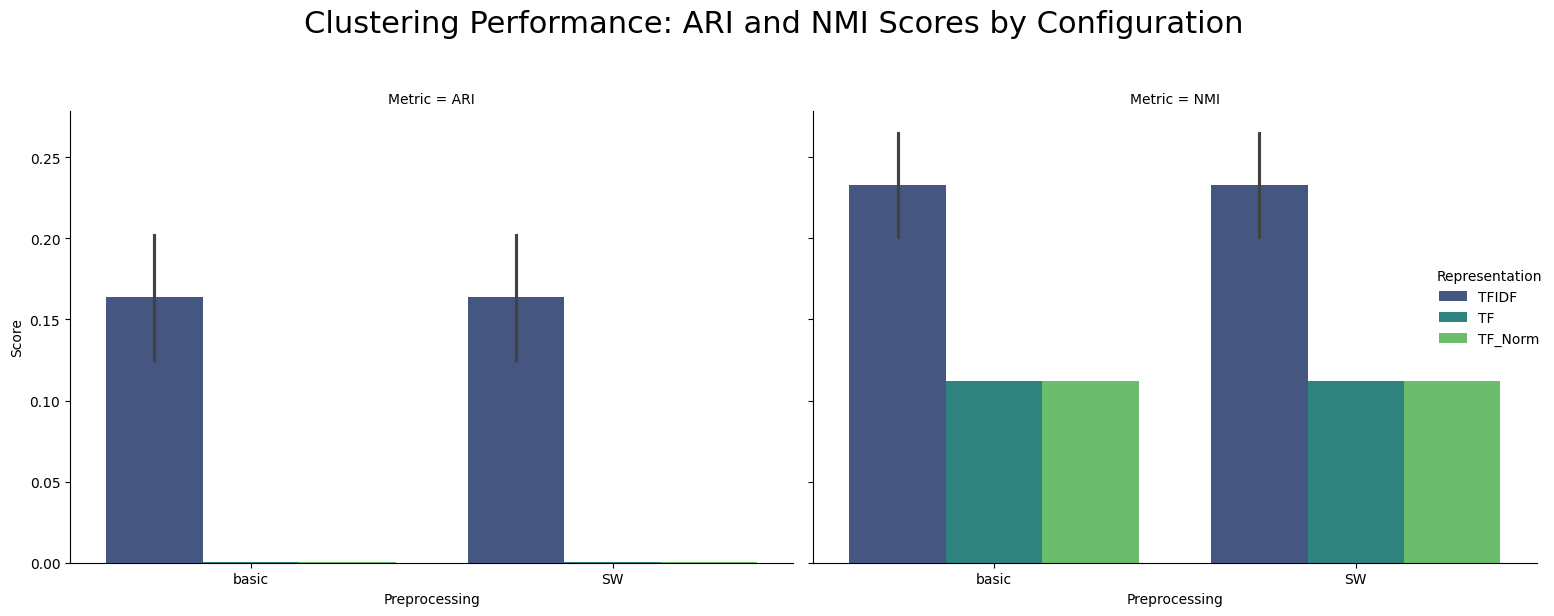

In [ ]:
res_melted = res_df.melt(id_vars=['Preprocessing', 'Representation', 'Algorithm'],
                       value_vars=['ARI', 'NMI'],
                       var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.catplot(data=res_melted,
            x='Preprocessing',
            y='Score',
            hue='Representation',
            col='Metric',
            kind='bar',
            palette='viridis',
            col_wrap=2,
            height=6, aspect=1.2) #

plt.suptitle('Clustering Performance: ARI and NMI Scores by Configuration', y=1.02, fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()